# 🏦 Bank Customer Churn Prediction

## Project Overview

This project develops a machine learning model to predict whether a customer is likely to leave **Beta Bank**.

The main challenge is the imbalance of the target variable: churned customers represent a minority of the observations. The analysis therefore compares different class-balancing strategies and optimizes a **Random Forest** model using **F1-score** as the primary metric.

The project requirement is to achieve an **F1-score of at least 0.59** on the test set. **ROC-AUC** is also measured as a complementary evaluation metric.

## 1. Data Loading and Preparation

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


In [2]:
# Data loading and initial analysis

data = pd.read_csv('../data/Churn.csv')

display(data.head())
print(data.shape)
data.info()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [3]:
# Data quality checks

print('Missing values:')
print(data.isna().sum())

print()
print('Duplicates:', data.duplicated().sum())

display(data.describe())

Valores ausentes:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Duplicados: 0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
# Handle missing values

data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

print(data.isna().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


### Missing-Value Treatment

The `Tenure` column contains 909 missing values. Because it represents the number of years a customer has been associated with the bank and its median is 5 years, the missing values are filled with the median.

Median imputation is appropriate here because it preserves the central tendency without being strongly affected by potential outliers.

In [5]:
# Remove identifier columns

data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

display(data.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


The columns `RowNumber`, `CustomerId`, and `Surname` are removed because they are identifiers rather than behavioral or financial characteristics expected to help predict churn.

In [6]:
# Finalize data preparation
data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

data = pd.get_dummies(data, drop_first=True)

print(data.isna().sum())
display(data.head())

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,0,1,0


### Data Preparation Summary

After preprocessing, no missing values remain. Missing `Tenure` values are replaced with the median, identifier columns are removed, and categorical variables are converted into numerical features using one-hot encoding.

The resulting dataset is ready for model training.

## 2. Class Balance and Baseline Model

0    0.7963
1    0.2037
Name: Exited, dtype: float64


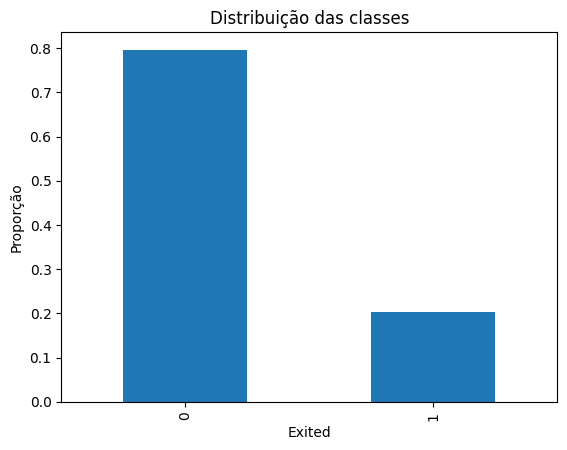

In [7]:
# Examine class balance

class_frequency = data['Exited'].value_counts(normalize=True)

print(class_frequency)
class_frequency.plot(kind='bar')
plt.title('Class distribution')
plt.xlabel('Exited')
plt.ylabel('Proportion')
plt.show()

In [8]:
# Split the data

target = data['Exited']
features = data.drop('Exited', axis=1)

features_train, features_temp, target_train, target_temp = train_test_split(
    features,
    target,
    test_size=0.40,
    random_state=12345,
    stratify=target
)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp,
    target_temp,
    test_size=0.50,
    random_state=12345,
    stratify=target_temp
)

print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)

(6000, 11)
(2000, 11)
(2000, 11)


In [9]:
# Feature scaling


numeric = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

features_train = features_train.copy()
features_valid = features_valid.copy()
features_test = features_test.copy()

scaler = StandardScaler()
scaler.fit(features_train[numeric])

features_train.loc[:, numeric] = scaler.transform(features_train[numeric])
features_valid.loc[:, numeric] = scaler.transform(features_valid[numeric])
features_test.loc[:, numeric] = scaler.transform(features_test[numeric])

In [10]:
# Baseline model

model = RandomForestClassifier(
    random_state=12345,
    n_estimators=100
)

model.fit(features_train, target_train)

predicted_valid = model.predict(features_valid)
probabilities_valid = model.predict_proba(features_valid)[:, 1]

print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid, probabilities_valid))

F1: 0.6126656848306332
AUC-ROC: 0.8623956177948565


### Baseline Model Summary

The target is clearly imbalanced: approximately **79.6%** of customers belong to class 0 (remained) and **20.4%** to class 1 (churned).

A baseline Random Forest model is first trained without correcting the imbalance. This establishes a reference point for evaluating whether class-balancing strategies improve churn detection.

## 3. Handling Class Imbalance and Model Selection

In [11]:
# Class weighting: test hyperparameter combinations

best_f1 = 0
best_depth = 0
best_estimators = 0
best_min_samples_split = 0

for estimators in [50, 100, 150, 200]:
    for depth in range(6, 16):
        for min_samples_split in [2, 5, 10]:
            model = RandomForestClassifier(
                random_state=12345,
                n_estimators=estimators,
                max_depth=depth,
                min_samples_split=min_samples_split,
                class_weight='balanced'
            )

            model.fit(features_train, target_train)
            predicted_valid = model.predict(features_valid)

            f1 = f1_score(target_valid, predicted_valid)

            if f1 > best_f1:
                best_f1 = f1
                best_depth = depth
                best_estimators = estimators
                best_min_samples_split = min_samples_split

print('Melhor F1:', best_f1)
print('Melhor profundidade:', best_depth)
print('Melhor número de árvores:', best_estimators)
print('Melhor min_samples_split:', best_min_samples_split)

Melhor F1: 0.6527777777777778
Melhor profundidade: 10
Melhor número de árvores: 50
Melhor min_samples_split: 10


In [12]:
# Apply upsampling

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat(
        [features_zeros] + [features_ones] * repeat
    )
    target_upsampled = pd.concat(
        [target_zeros] + [target_ones] * repeat
    )

    features_upsampled, target_upsampled = shuffle(
        features_upsampled,
        target_upsampled,
        random_state=12345
    )

    return features_upsampled, target_upsampled


features_upsampled, target_upsampled = upsample(
    features_train,
    target_train,
    4
)

print(target_upsampled.value_counts(normalize=True))

1    0.50569
0    0.49431
Name: Exited, dtype: float64


In [13]:
# Evaluate tree depths with upsampled data

best_f1_upsampled = 0
best_depth_upsampled = 0

for depth in range(2, 16):
    model = RandomForestClassifier(
        random_state=12345,
        n_estimators=100,
        max_depth=depth
    )

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)

    f1 = f1_score(target_valid, predicted_valid)

    if f1 > best_f1_upsampled:
        best_f1_upsampled = f1
        best_depth_upsampled = depth

print('Melhor F1:', best_f1_upsampled)
print('Melhor profundidade:', best_depth_upsampled)

Melhor F1: 0.6436781609195401
Melhor profundidade: 11


### Improving the Model

Two approaches are evaluated to address class imbalance:

1. **Class weighting** using `class_weight='balanced'`.
2. **Upsampling** the minority class.

Random Forest hyperparameters are evaluated on the validation set and the approaches are compared using F1-score. The class-weighted model provides the strongest validation result and is selected for final testing.

## 4. Final Model Evaluation

In [14]:
# Evaluate the selected model on the test set


final_model = RandomForestClassifier(
    random_state=12345,
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced'
)

final_model.fit(features_train, target_train)

predicted_test = final_model.predict(features_test)
probabilities_test = final_model.predict_proba(features_test)[:, 1]

f1_test = f1_score(target_test, predicted_test)
auc_roc_test = roc_auc_score(target_test, probabilities_test)

print('F1 no conjunto de teste:', f1_test)
print('AUC-ROC no conjunto de teste:', auc_roc_test)

F1 no conjunto de teste: 0.6033653846153847
AUC-ROC no conjunto de teste: 0.8521310216225472


### Final Test Results

On the test set, the selected Random Forest model achieves an **F1-score of approximately 0.603**, exceeding the project requirement of **0.59**.

The model also achieves a **ROC-AUC of approximately 0.852**, indicating good ability to distinguish between customers who churn and customers who remain.

F1-score is particularly important for this problem because it balances precision and recall for the minority churn class, while ROC-AUC provides a broader view of ranking performance across classification thresholds.

## Final Conclusion

This project developed a machine learning model to predict customers who are more likely to leave Beta Bank.

The workflow included missing-value treatment, removal of identifier columns, categorical encoding, feature scaling, class-balance analysis, baseline modeling, and evaluation of two imbalance-handling strategies.

Both **class weighting** and **upsampling** were tested. After validation and hyperparameter comparison, the class-weighted Random Forest was selected as the final model.

On the test set, the model achieved:

- **F1-score: ~0.603**
- **ROC-AUC: ~0.852**

The F1-score exceeds the required threshold of 0.59, while the ROC-AUC result indicates useful discrimination between churned and retained customers.

From a business perspective, this type of model could support retention initiatives by helping prioritize customers for proactive engagement. The model identifies statistical patterns associated with churn; it does not establish that individual customer characteristics cause churn.

### Limitations

The analysis is based on the available historical dataset and does not incorporate the financial cost of false positives and false negatives. In a production setting, model performance should be monitored over time, and the classification threshold could be optimized according to retention costs and customer value.